In [81]:
import numpy as np
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
import numpy as np
import matplotlib.pyplot as plt

In [83]:
from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay

In [85]:
roc_curve = RocCurveDisplay.from_estimator

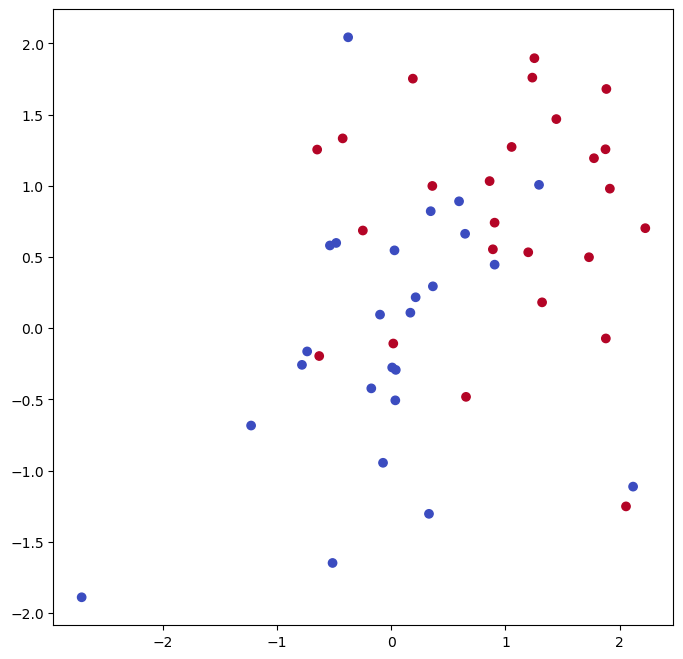

In [87]:
rng = np.random.default_rng(1)
X = rng.standard_normal((50, 2))
y = np.array([-1]*25+[1]*25)
X[y==1] += 1
fig, ax = subplots(figsize=(8,8))
ax.scatter(X[:,0],
           X[:,1],
           c=y,
           cmap=cm.coolwarm);

In [89]:
svm_linear = SVC(C=10, kernel='linear')
svm_linear.fit(X, y)

SVC(C=10, kernel='linear')

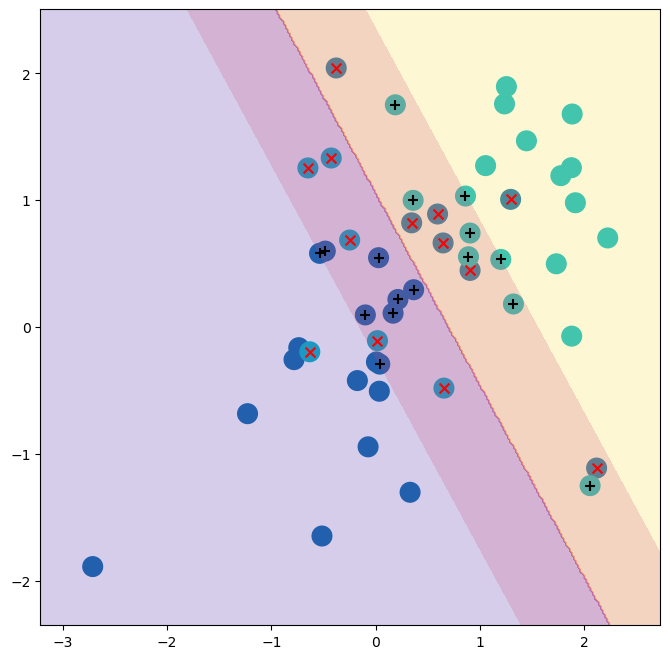

In [91]:
fig, ax = subplots(figsize=(8,8))
plot_svm(X,
         y,
         svm_linear,
         ax=ax)

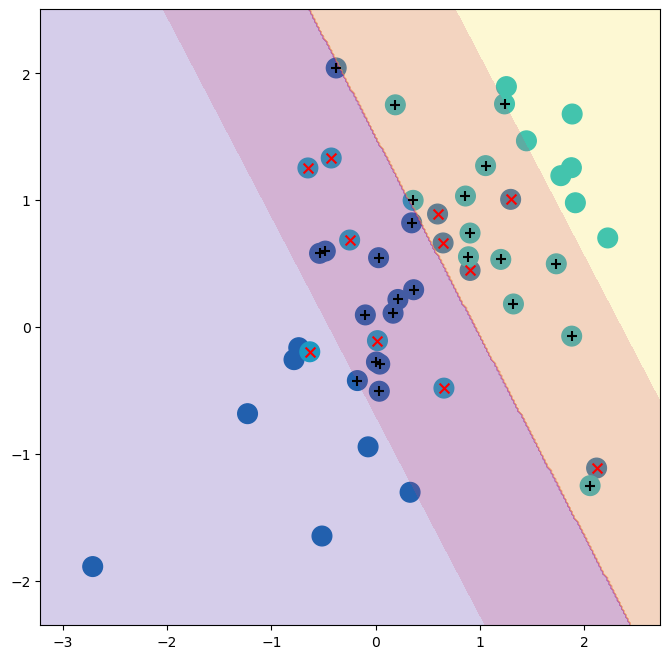

In [92]:
svm_linear_small = SVC(C=0.1, kernel='linear')
svm_linear_small.fit(X, y)
fig, ax = subplots(figsize=(8,8))
plot_svm(X,
         y,
         svm_linear_small,
         ax=ax)

In [94]:
svm_linear.coef_

array([[1.17303943, 0.77348227]])

In [95]:
kfold = skm.KFold(5, 
                  random_state=0,
                  shuffle=True)
grid = skm.GridSearchCV(svm_linear,
                        {'C':[0.001,0.01,0.1,1,5,10,100]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy')
grid.fit(X, y)
grid.best_params_

{'C': 1}

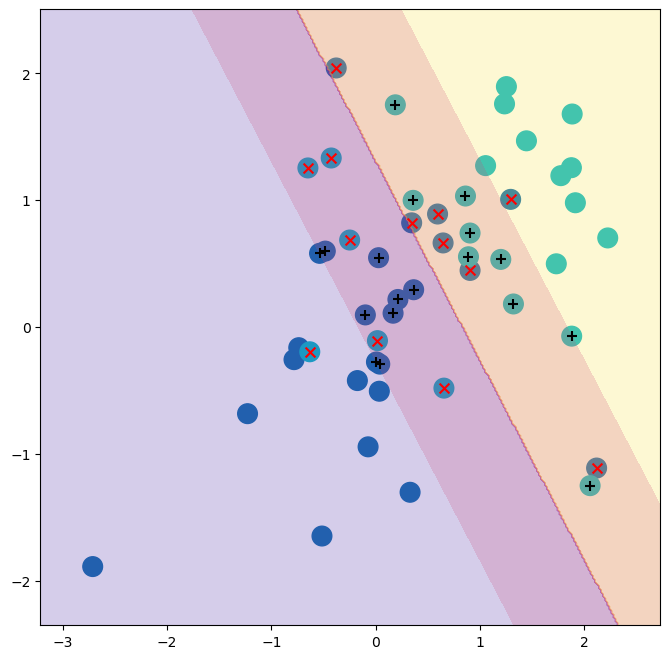

In [97]:
svm_linear_small = SVC(C=1, kernel='linear')
svm_linear_small.fit(X, y)
fig, ax = subplots(figsize=(8,8))
plot_svm(X,
         y,
         svm_linear_small,
         ax=ax)

In [100]:
grid.cv_results_[('mean_test_score')]

array([0.46, 0.46, 0.72, 0.74, 0.74, 0.74, 0.74])

In [101]:
X_test = rng.standard_normal((20, 2))
y_test = np.array([-1]*10+[1]*10)
X_test[y_test==1] += 1

In [105]:
best_ = grid.best_estimator_
y_test_hat = best_.predict(X_test)
confusion_table(y_test_hat, y_test)

Truth,-1,1
Predicted,,
-1,8,4
1,2,6


In [107]:
svm_ = SVC(C=0.001,
           kernel='linear').fit(X, y)
y_test_hat = svm_.predict(X_test)
confusion_table(y_test_hat, y_test)

Truth,-1,1
Predicted,,
-1,2,0
1,8,10


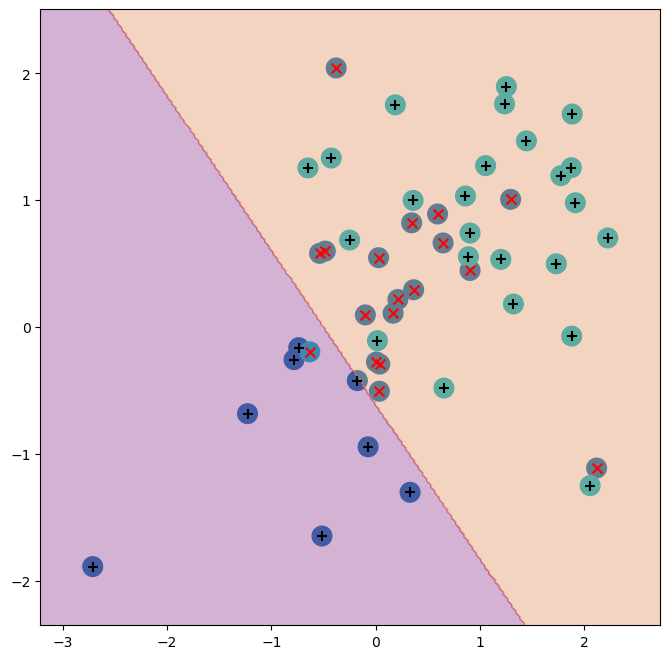

In [109]:
svm_linear_small = SVC(C=0.001, kernel='linear')
svm_linear_small.fit(X, y)
fig, ax = subplots(figsize=(8,8))
plot_svm(X,
         y,
         svm_linear_small,
         ax=ax)

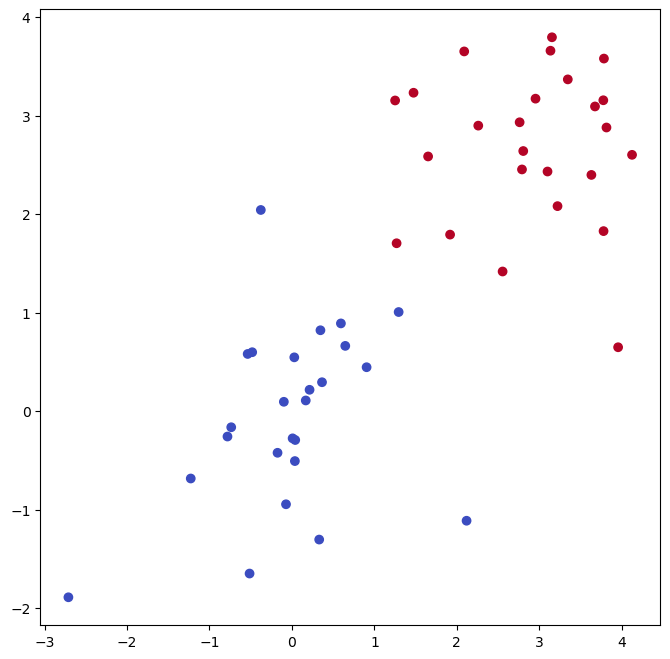

In [110]:
X[y==1] += 1.9;
fig, ax = subplots(figsize=(8,8))
ax.scatter(X[:,0], X[:,1], c=y, cmap=cm.coolwarm);

In [112]:
svm_ = SVC(C=1e5, kernel='linear').fit(X, y)
y_hat = svm_.predict(X)
confusion_table(y_hat, y)

Truth,-1,1
Predicted,,
-1,25,0
1,0,25


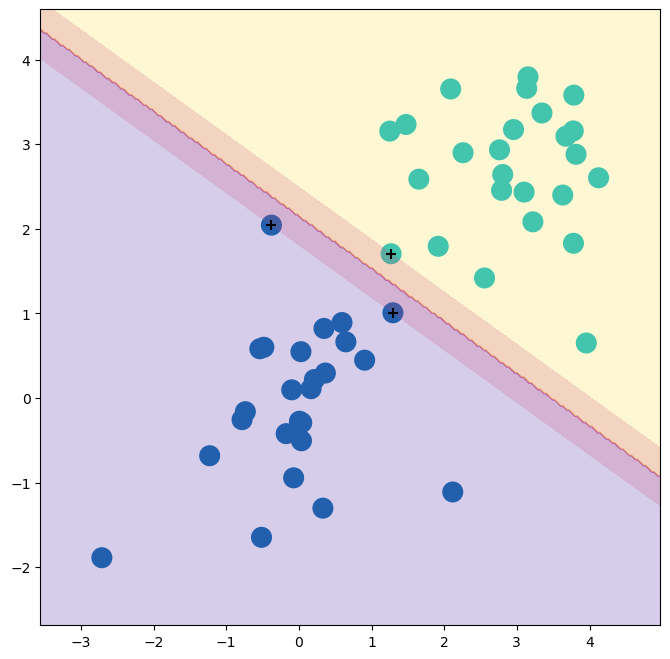

In [115]:
fig, ax = subplots(figsize=(8,8))
plot_svm(X,
         y,
         svm_,
         ax=ax)

In [116]:
svm_ = SVC(C=0.1, kernel='linear').fit(X, y)
y_hat = svm_.predict(X)
confusion_table(y_hat, y)

Truth,-1,1
Predicted,,
-1,25,0
1,0,25


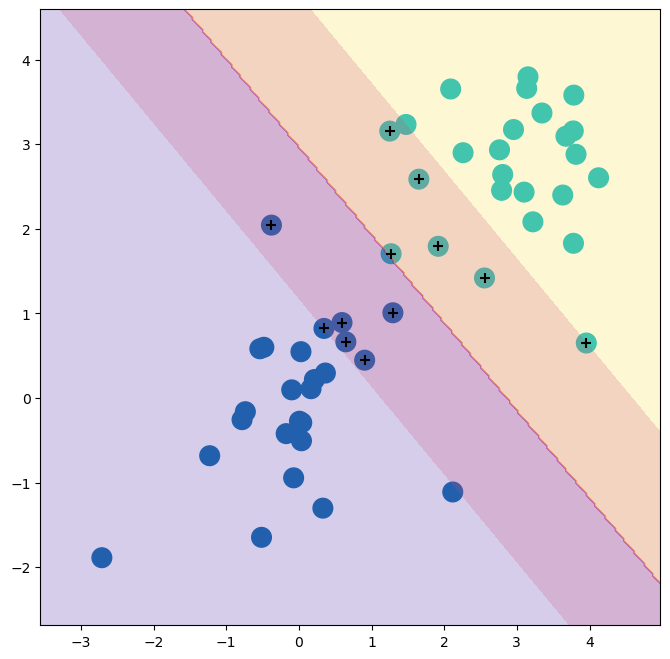

In [119]:
fig, ax = subplots(figsize=(8,8))
plot_svm(X,
         y,
         svm_,
         ax=ax)

In [120]:
X = rng.standard_normal((200, 2))
X[:100] += 2
X[100:150] -= 2
y = np.array([1]*150+[2]*50)

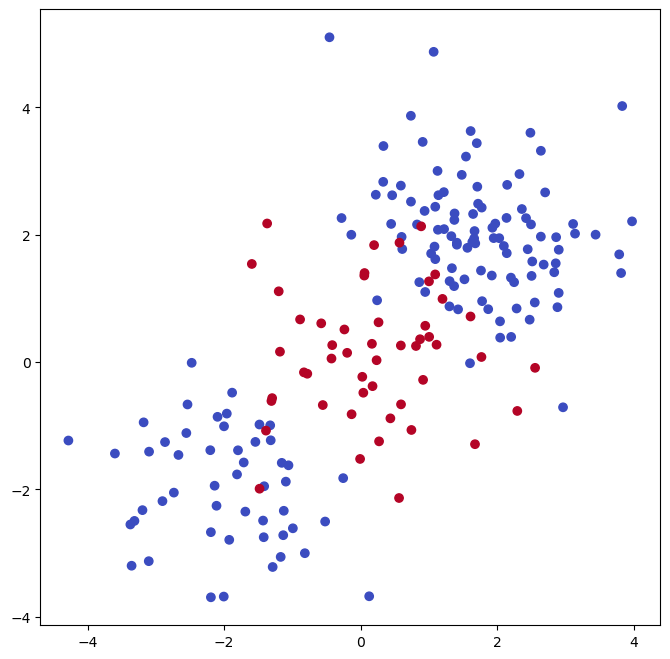

In [123]:
fig, ax = subplots(figsize=(8,8))
ax.scatter(X[:,0],
           X[:,1],
           c=y,
           cmap=cm.coolwarm)

In [125]:
(X_train, 
 X_test,
 y_train,
 y_test) = skm.train_test_split(X,
                                y,
                                test_size=0.5,
                                random_state=0)
svm_rbf = SVC(kernel="rbf", gamma=1, C=1)
svm_rbf.fit(X_train, y_train)

SVC(C=1, gamma=1)

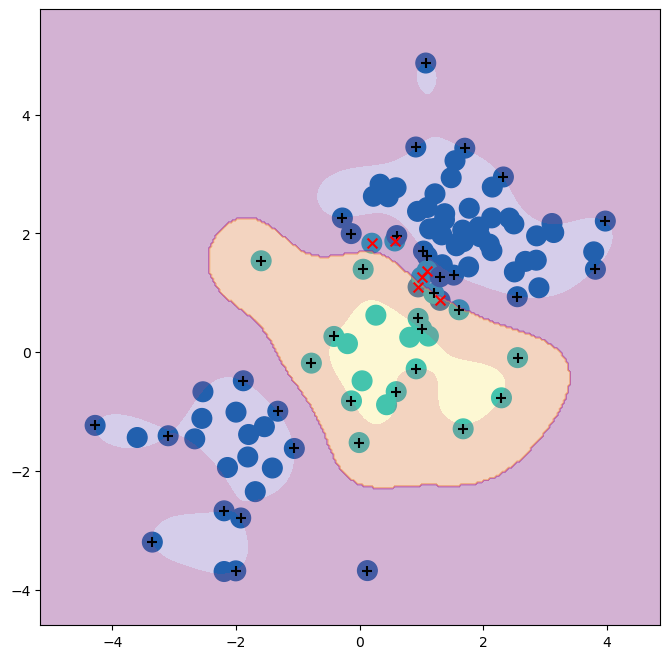

In [127]:
fig, ax = subplots(figsize=(8,8))
plot_svm(X_train,
         y_train,
         svm_rbf,
         ax=ax)

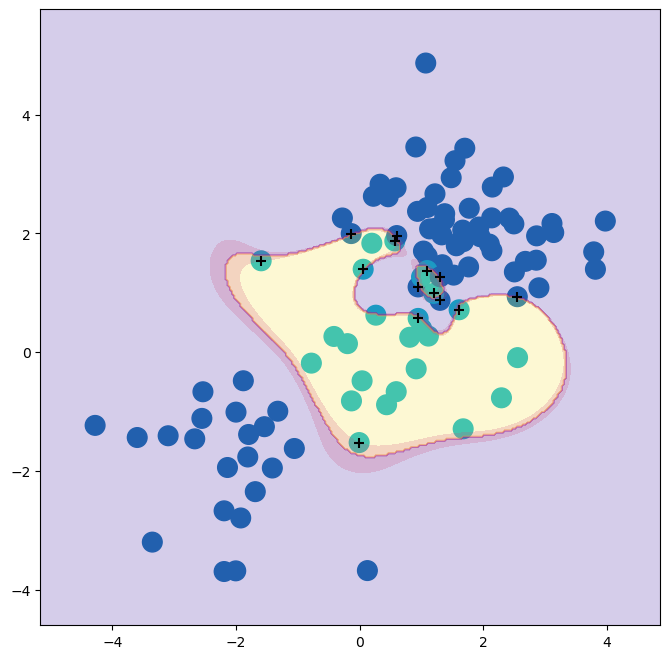

In [128]:
svm_rbf = SVC(kernel="rbf", gamma=1, C=1e5)
svm_rbf.fit(X_train, y_train)
fig, ax = subplots(figsize=(8,8))
plot_svm(X_train,
         y_train,
         svm_rbf,
         ax=ax)

In [129]:
kfold = skm.KFold(5, 
                  random_state=0,
                  shuffle=True)
grid = skm.GridSearchCV(svm_rbf,
                        {'C':[0.1,1,10,100,1000],
                         'gamma':[0.5,1,2,3,4]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy');
grid.fit(X_train, y_train)
grid.best_params_

{'C': 1, 'gamma': 0.5}

Truth,1,2
Predicted,,
1,69,6
2,6,19


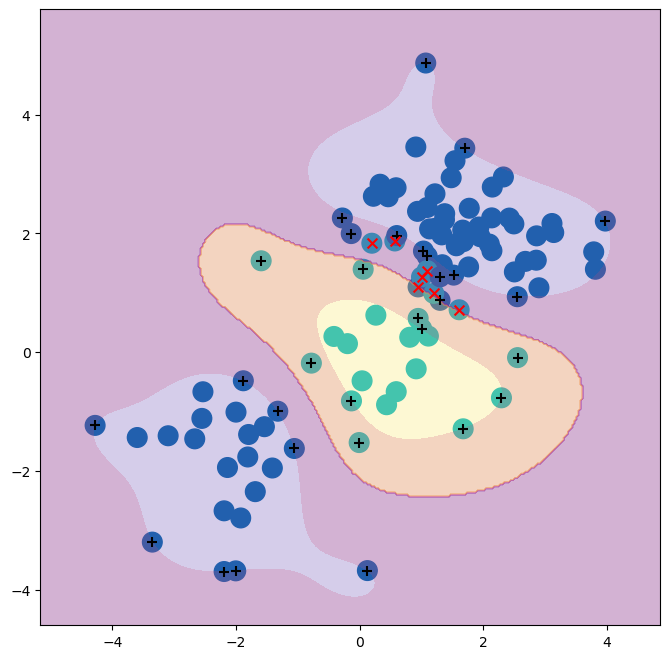

In [130]:
best_svm = grid.best_estimator_
fig, ax = subplots(figsize=(8,8))
plot_svm(X_train,
         y_train,
         best_svm,
         ax=ax)

y_hat_test = best_svm.predict(X_test)
confusion_table(y_hat_test, y_test)

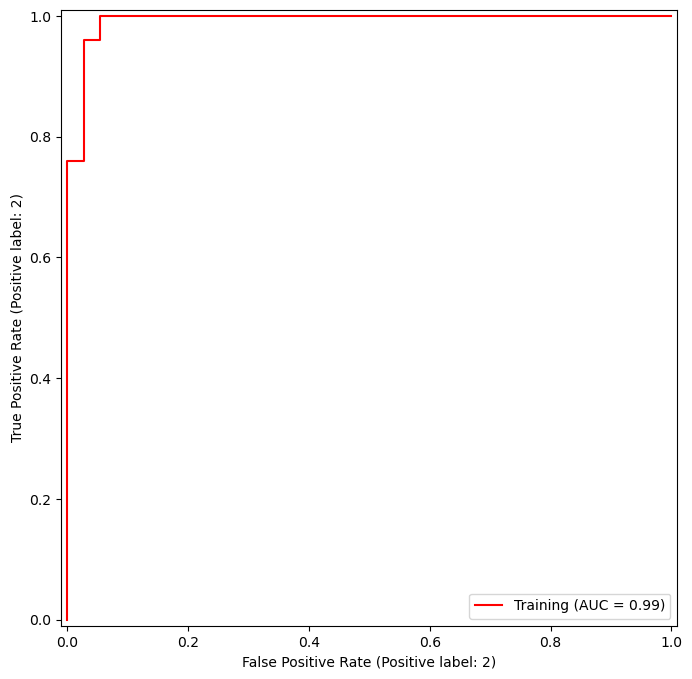

In [131]:
fig, ax = subplots(figsize=(8,8))
roc_curve(best_svm,
          X_train,
          y_train,
          name='Training',
          color='r',
          ax=ax)

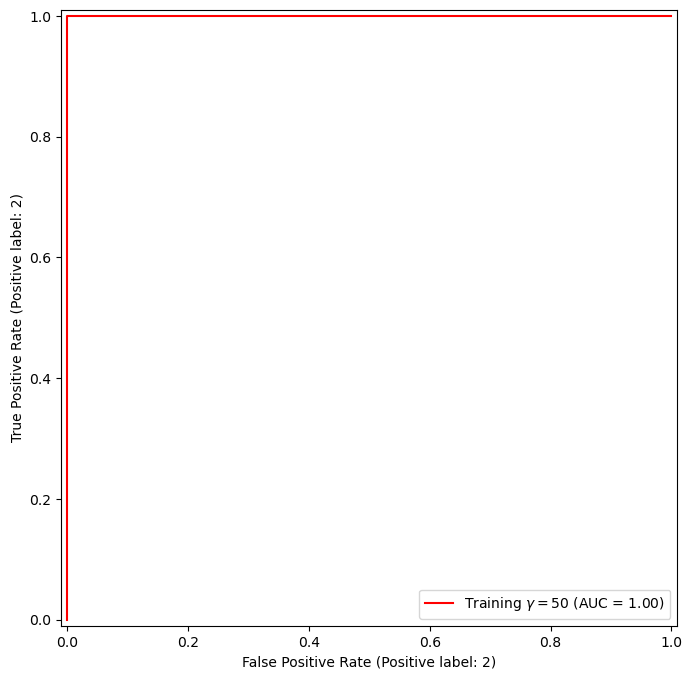

In [133]:
svm_flex = SVC(kernel="rbf", 
              gamma=50,
              C=1)
svm_flex.fit(X_train, y_train)
fig, ax = subplots(figsize=(8,8))
roc_curve(svm_flex,
          X_train,
          y_train,
          #name='Training $\gamma=50$'
          name=r'Training $\gamma=50$',
          color='r',
          ax=ax)

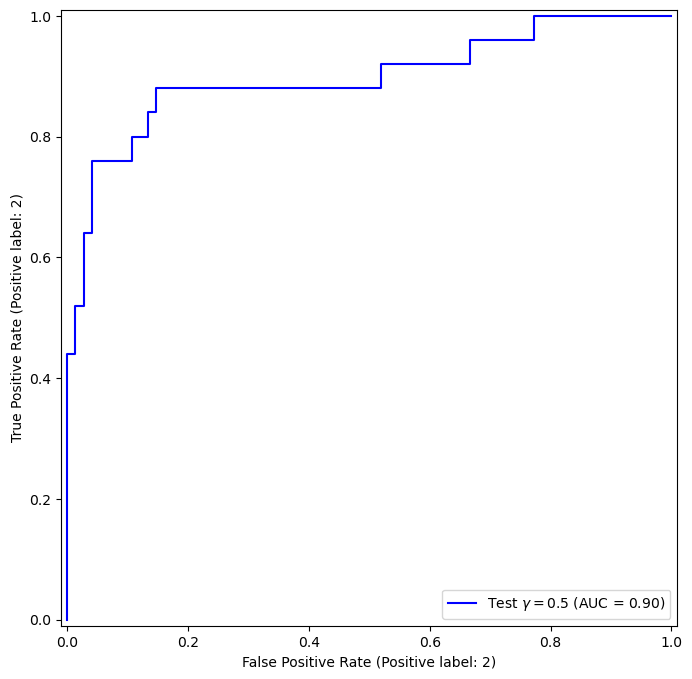

In [134]:
fig, ax = subplots(figsize=(8,8))
roc_curve(best_svm,
          X_test,
          y_test,
          #name='Test $\gamma=0.5$',
          name=r'Test $\gamma=0.5$',
          color='b',
          ax=ax)

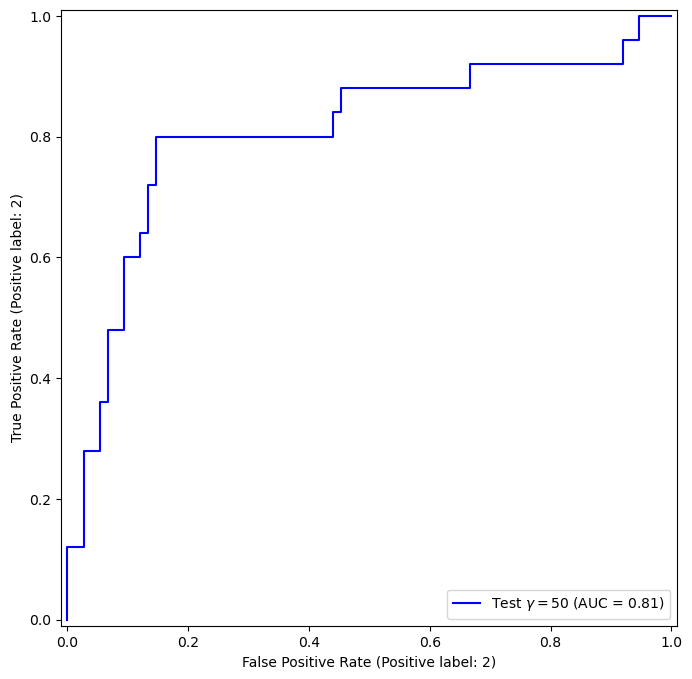

In [136]:
fig, ax = subplots(figsize=(8,8))
roc_curve(svm_flex,
          X_test,
          y_test,
          #name='Test $\gamma=50$',
          name=r'Test $\gamma=50$',
          color='b',
          ax=ax)

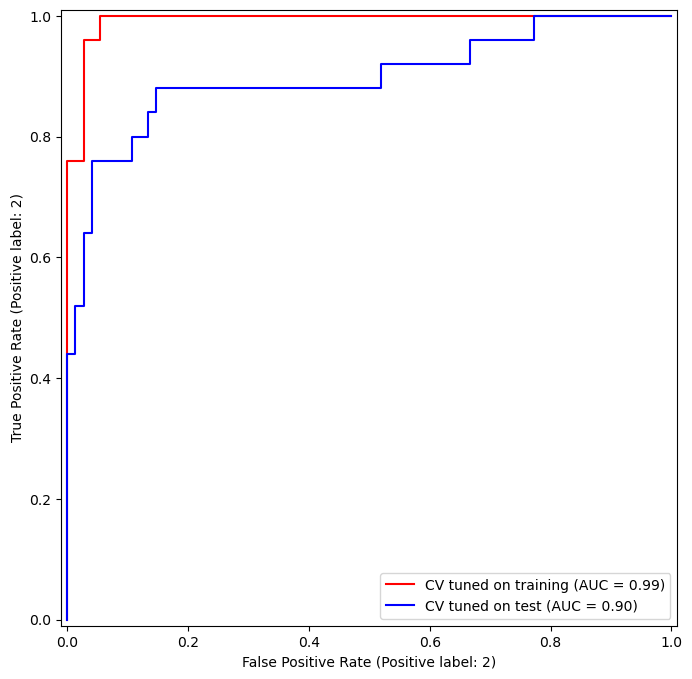

In [138]:
fig, ax = subplots(figsize=(8,8))
for (X_, y_, c, name) in zip(
     (X_train, X_test),
     (y_train, y_test),
     ('r', 'b'),
     ('CV tuned on training',
      'CV tuned on test')):
    roc_curve(best_svm,
              X_,
              y_,
              name=name,
              ax=ax,
              color=c)

In [139]:
np.vstack?

Signature:       np.vstack(tup, *, dtype=None, casting='same_kind')
Call signature:  np.vstack(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function vstack at 0x0000019C2B2B0360>
File:            c:\users\u\anaconda3\lib\site-packages\numpy\core\shape_base.py
Docstring:      
Stack arrays in sequence vertically (row wise).

This is equivalent to concatenation along the first axis after 1-D arrays
of shape `(N,)` have been reshaped to `(1,N)`. Rebuilds arrays divided by
`vsplit`.

This function makes most sense for arrays with up to 3 dimensions. For
instance, for pixel-data with a height (first axis), width (second axis),
and r/g/b channels (third axis). The functions `concatenate`, `stack` and
`block` provide more general stacking and concatenation operations.

``np.row_stack`` is an alias for `vstack`. They are the same function.

Parameters
----------
tup : sequence of ndarrays
    The arrays must have the same shape along all but the first axis.
    

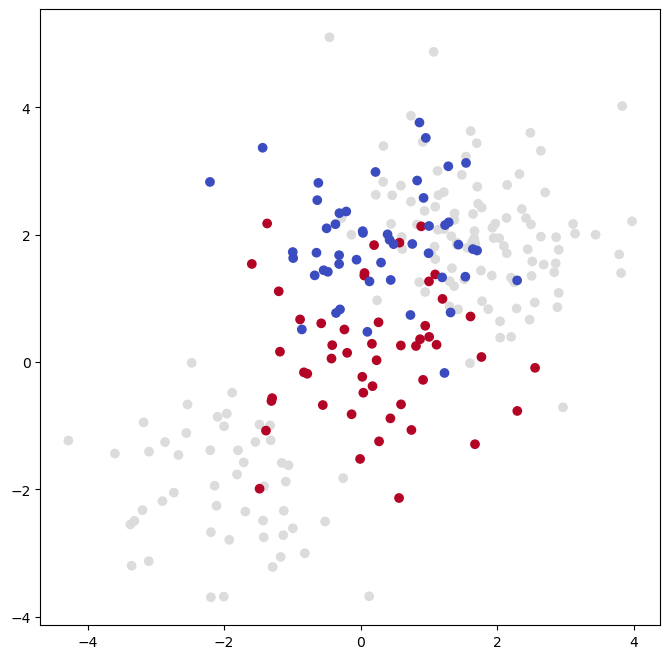

In [140]:
rng = np.random.default_rng(123)
X = np.vstack([X, rng.standard_normal((50, 2))])
y = np.hstack([y, [0]*50])
X[y==0,1] += 2
fig, ax = subplots(figsize=(8,8))
ax.scatter(X[:,0], X[:,1], c=y, cmap=cm.coolwarm)

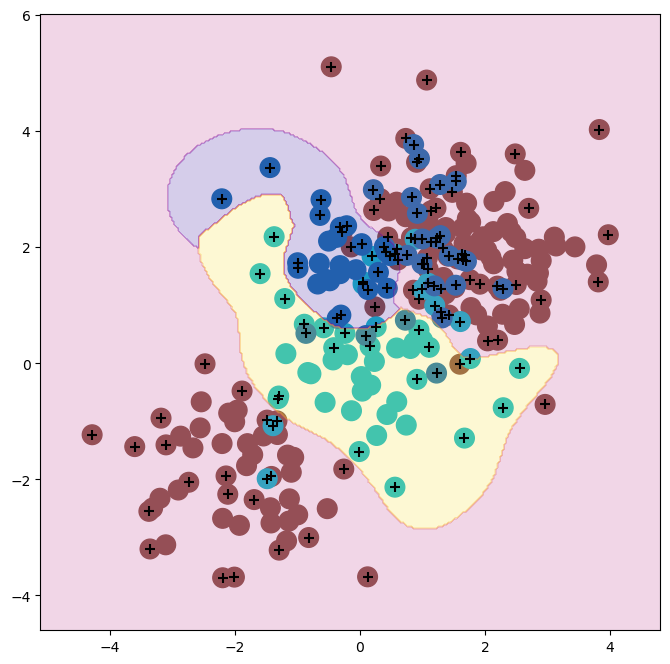

In [141]:
svm_rbf_3 = SVC(kernel="rbf",
                C=10,
                gamma=1,
                decision_function_shape='ovo');
svm_rbf_3.fit(X, y)
fig, ax = subplots(figsize=(8,8))
plot_svm(X,
         y,
         svm_rbf_3,
         scatter_cmap=cm.tab10,
         ax=ax)

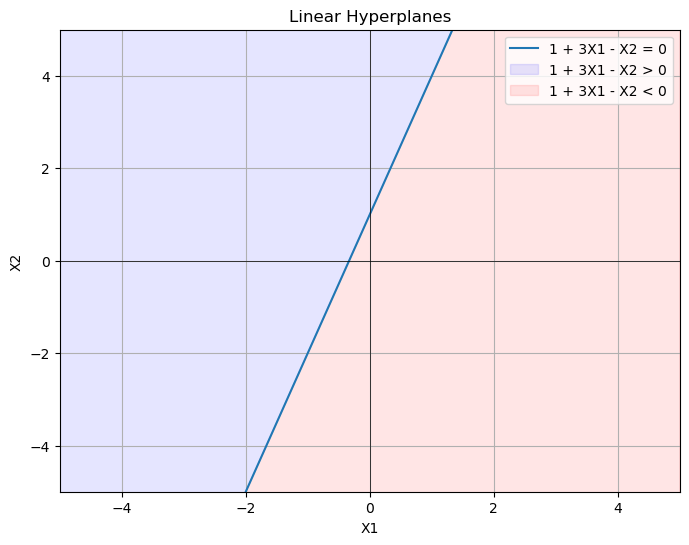

In [155]:
# 데이터 범위 설정
x1_vals = np.linspace(-5, 5, 200)

# 초평면 1: 1 + 3X1 - X2 = 0 → X2 = 3X1 + 1
x2_line1 = 3 * x1_vals + 1

# 그림 그리기
plt.figure(figsize=(8, 6))
plt.plot(x1_vals, x2_line1, label='1 + 3X1 - X2 = 0')

# 영역 색칠 (시각화용)
plt.fill_between(x1_vals, x2_line1, 10, color='blue', alpha=0.1, label='1 + 3X1 - X2 > 0')
plt.fill_between(x1_vals, -10, x2_line1, color='red', alpha=0.1, label='1 + 3X1 - X2 < 0')

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.title("Linear Hyperplanes")
plt.grid(True)
plt.show()

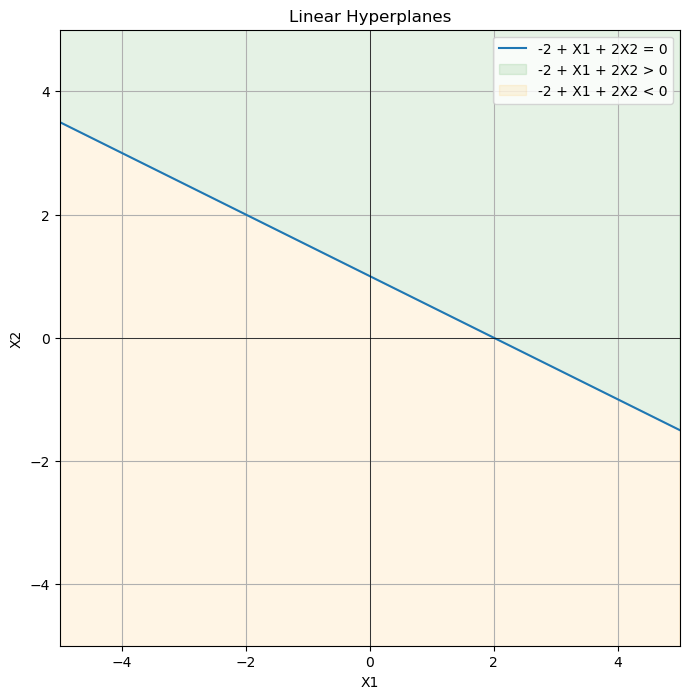

In [153]:
# 데이터 범위 설정
x1_vals = np.linspace(-5, 5, 200)

# 초평면 2: -2 + X1 + 2X2 = 0 → X2 = (2 - X1)/2
x2_line2 = (2 - x1_vals) / 2

# 그림 그리기
plt.figure(figsize=(8, 8))
plt.plot(x1_vals, x2_line2, label='-2 + X1 + 2X2 = 0')

# 영역 색칠 (시각화용)
plt.fill_between(x1_vals, x2_line2, 10, color='green', alpha=0.1, label='-2 + X1 + 2X2 > 0')
plt.fill_between(x1_vals, -10, x2_line2, color='orange', alpha=0.1, label='-2 + X1 + 2X2 < 0')

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.title("Linear Hyperplanes")
plt.grid(True)
plt.show()

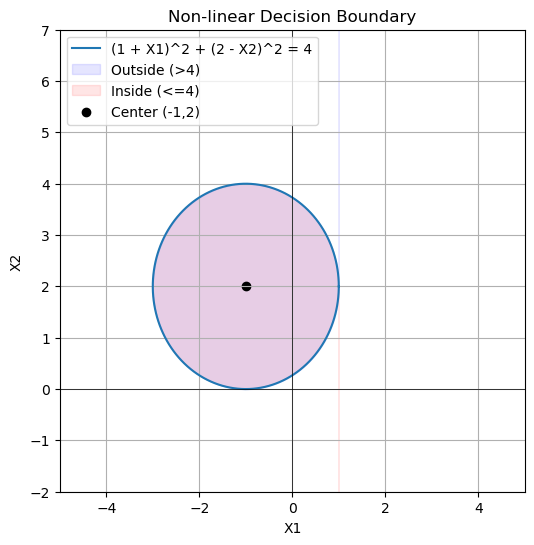

In [157]:
theta = np.linspace(0, 2 * np.pi, 300)
r = 2  # 반지름
center = (-1, 2)
x_circle = center[0] + r * np.cos(theta)
y_circle = center[1] + r * np.sin(theta)

plt.figure(figsize=(6, 6))
plt.plot(x_circle, y_circle, label='(1 + X1)^2 + (2 - X2)^2 = 4')
plt.fill_between(x_circle, y_circle, 10, color='blue', alpha=0.1, label='Outside (>4)')
plt.fill_between(x_circle, -10, y_circle, color='red', alpha=0.1, label='Inside (<=4)')

plt.scatter(*center, color='black', label='Center (-1,2)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlim(-5, 5)
plt.ylim(-2, 7)
plt.grid(True)
plt.legend()
plt.title("Non-linear Decision Boundary")
plt.show()

In [159]:
def classify(x1, x2):
    val = (1 + x1)**2 + (2 - x2)**2
    if val > 4:
        return 'Blue class'
    else:
        return 'Red class'

test_points = [(0, 0), (-1, 1), (2, 2), (3, 8)]

for pt in test_points:
    x1, x2 = pt
    result = classify(x1, x2)
    print(f'Point {pt} is classified as: {result}')

Point (0, 0) is classified as: Blue class
Point (-1, 1) is classified as: Red class
Point (2, 2) is classified as: Blue class
Point (3, 8) is classified as: Blue class


In [161]:
from sympy import symbols, expand

X1, X2 = symbols('X1 X2')
expr = (1 + X1)**2 + (2 - X2)**2 - 4
expanded = expand(expr)
print("Expanded Decision Function:")
print(expanded)

Expanded Decision Function:
X1**2 + 2*X1 + X2**2 - 4*X2 + 1


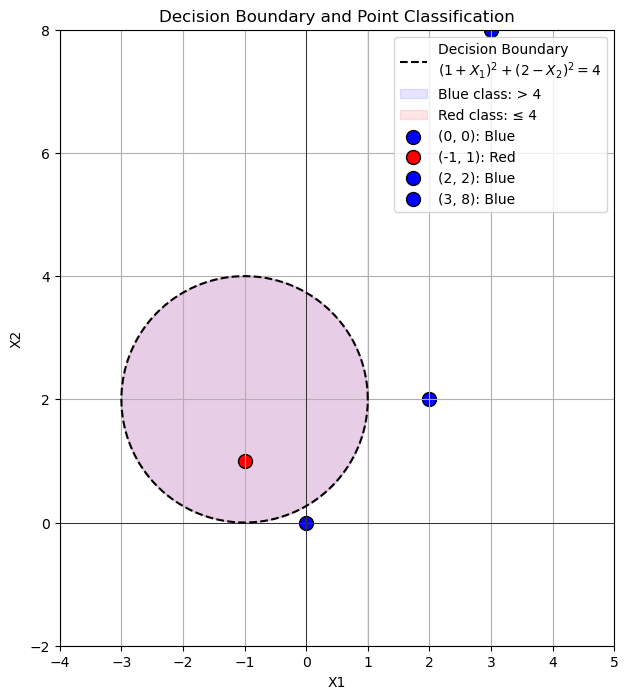

In [164]:
# 원의 중심과 반지름
center = (-1, 2)
radius = 2

# 원 그리기용 좌표
theta = np.linspace(0, 2 * np.pi, 300)
x_circle = center[0] + radius * np.cos(theta)
y_circle = center[1] + radius * np.sin(theta)

# (c) 테스트 포인트 목록
test_points = [(0, 0), (-1, 1), (2, 2), (3, 8)]

def classify_point(x1, x2):
    val = (1 + x1)**2 + (2 - x2)**2
    return 'blue' if val > 4 else 'red'

# 그래프 그리기
plt.figure(figsize=(8, 8))
plt.plot(x_circle, y_circle, 'k--', label='Decision Boundary\n$(1+X_1)^2 + (2-X_2)^2 = 4$')
plt.fill_between(x_circle, y_circle, 10, color='blue', alpha=0.1, label='Blue class: > 4')
plt.fill_between(x_circle, -10, y_circle, color='red', alpha=0.1, label='Red class: ≤ 4')

# 테스트 포인트 표시
for x1, x2 in test_points:
    color = classify_point(x1, x2)
    plt.scatter(x1, x2, c=color, s=100, edgecolors='black', label=f'{(x1,x2)}: {color.capitalize()}')

# 범례 중복 제거
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
plt.legend(unique_labels.values(), unique_labels.keys(), loc='upper right')

plt.title("Decision Boundary and Point Classification")
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True)
plt.xlim(-4, 5)
plt.ylim(-2, 8)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.gca().set_aspect('equal')  # 원형 비율 유지
plt.show()